In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold,GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import PolynomialFeatures



from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import classification_report, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("bodyPerformance.csv")


In [ ]:
# 1. Duplicates
dupes = df.duplicated().sum()
if dupes > 0:
    print(f"Found {dupes} duplicate rows ({dupes/len(df)*100}%).")
    df = df.drop_duplicates()
else:
    print("No exact duplicates found.")

# 2. Null Values
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    print(f"\nFound Null Values in {len(nulls)} columns:")
    print(nulls)

    # Decision Logic for Nulls
    for col in nulls.index:
        pct_missing = (df[col].isnull().sum() / len(df2)) * 100
        print(f"Example Strategy for '{col}' ({pct_missing}% missing):")
else:
    print("No missing values found.")

Found 1 duplicate rows (0.007466587023071754%).
No missing values found.


In [ ]:
print("=== 1. Detecting Violations ===")

invalid_weights = df[df['weight_kg'] < 0]
print(f"- Negative weights found: {len(invalid_weights)}")

invalid_ages = df[(df['age'] < 10) | (df['age'] > 100)]
print(f"- Unrealistic ages found: {len(invalid_ages)}")

invalid_bodyfat = df[(df['body fat_%'] < 3) | (df['body fat_%'] > 60)]
print(f"- Unrealistic body fat ratio found: {len(invalid_bodyfat)}")

invalid_flexibility = df[
    (df['sit and bend forward_cm'] < -30) |
    (df['sit and bend forward_cm'] > 60)
]
print(f"- Unrealistic flexibility found: {len(invalid_flexibility)}")

abnormal_bp = df[
    (df['systolic'] <= df['diastolic']) |
    (df['systolic'] < 50) |
    (df['diastolic'] < 30)
]
print(f"- Abnormal blood pressure readings found: {len(abnormal_bp)}")

if len(abnormal_bp) > 0:
    print("\nSample of Abnormal Blood Pressure rows:")
    print(abnormal_bp[['age', 'gender', 'systolic', 'diastolic']])

if len(invalid_bodyfat) > 0:
    print(invalid_bodyfat[['age', 'gender', 'systolic', 'diastolic', 'body fat_%']])

if len(invalid_flexibility) > 0:
    print(invalid_flexibility[['age', 'gender', 'systolic', 'diastolic', 'body fat_%', 'sit and bend forward_cm']])




=== 1. Detecting Violations ===
- Negative weights found: 0
- Unrealistic ages found: 0
- Unrealistic body fat ratio found: 1
- Unrealistic flexibility found: 2
- Abnormal blood pressure readings found: 7

Sample of Abnormal Blood Pressure rows:
        age gender  systolic  diastolic
336    35.0      M     122.0        8.0
3524   44.0      M     145.0        6.0
7495   30.0      F     104.0      156.2
7597   30.0      M      14.0       67.0
8217   31.0      M      43.9       46.2
10624  26.0      F       0.0        0.0
12949  24.0      M      95.0       99.0
      age gender  systolic  diastolic  body fat_%
735  21.0      M     122.0       69.0        78.4
       age gender  systolic  diastolic  body fat_%  sit and bend forward_cm
2657  33.0      M     127.0       81.0        17.8                    213.0
3355  45.0      M     142.0       96.0        24.3                    185.0


In [ ]:
print("=== 2. Cleaning the Data (Removing Violations) ===")

# We use set() to avoid duplicates in case a single row has multiple issues (e.g., invalid weight AND abnormal BP).
bad_indices = set(
    invalid_weights.index.tolist() +
    invalid_ages.index.tolist() +
    invalid_bodyfat.index.tolist() +
    invalid_flexibility.index.tolist() +
    abnormal_bp.index.tolist())

#  Drop all these rows at once from the dataframe.
df_cleaned = df.drop(index=list(bad_indices))


print(" Cleaning completed successfully!")
print(f"- Rows before cleaning: {len(df)}")
print(f"- Rows removed: {len(bad_indices)}")
print(f"- Rows after cleaning: {len(df_cleaned)}")

df = df_cleaned.copy()

=== 2. Cleaning the Data (Removing Violations) ===
 Cleaning completed successfully!
- Rows before cleaning: 13392
- Rows removed: 10
- Rows after cleaning: 13382


### **الموديل من اول هنا هناخده كوبي للفايل الكبيبر**

In [ ]:
df_reg = df.copy()

le = LabelEncoder()
df_reg['gender'] = le.fit_transform(df_reg['gender'])
df_reg['class'] = le.fit_transform(df_reg['class'])

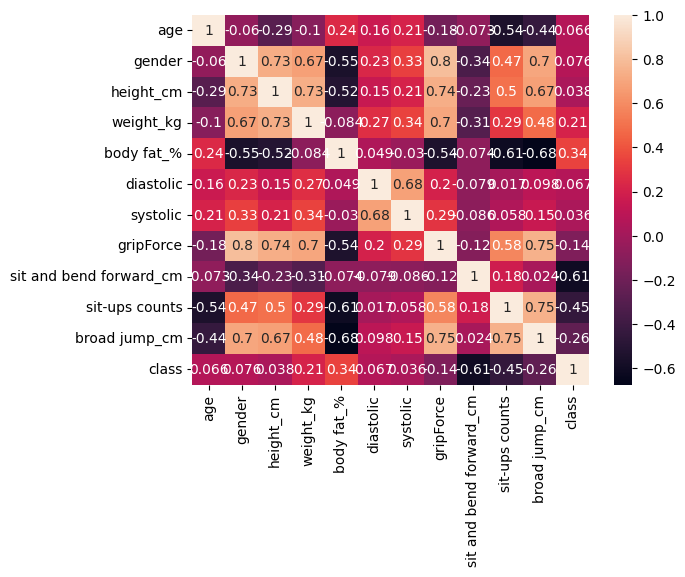

In [ ]:
sns.heatmap(df_reg.corr(), annot=True)
plt.show()

### **REMOVE OUTLIERS (Z-SCORE)**

In [ ]:
numeric_df = df_reg.select_dtypes(include=np.number)
z_scores = np.abs((numeric_df - numeric_df.mean()) / numeric_df.std())
df_clean = df_reg[(z_scores < 3).all(axis=1)]
print(f"Original shape: {df_reg.shape}")
print(f"Shape after removing outliers: {df_clean.shape}")
print(f"Number of rows removed: {df_reg.shape[0] - df_clean.shape[0]}")
df_reg = df_clean.copy()

Original shape: (13382, 12)
Shape after removing outliers: (13019, 12)
Number of rows removed: 363


Applied Log Transformation on target (broad jump_cm)


  Split 80:20  =>  After Log Transformation
  MSE  : 329.0002
  RMSE : 18.1384
  R2   : 0.7810 (78.10%)


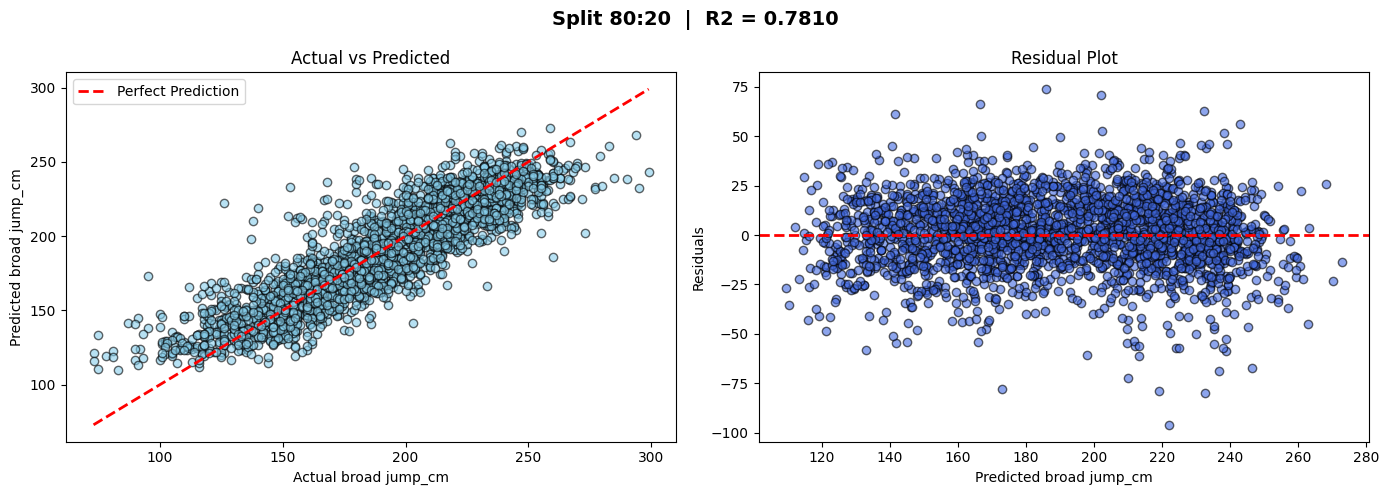


  Split 70:30  =>  After Log Transformation
  MSE  : 328.3357
  RMSE : 18.1200
  R2   : 0.7804 (78.04%)


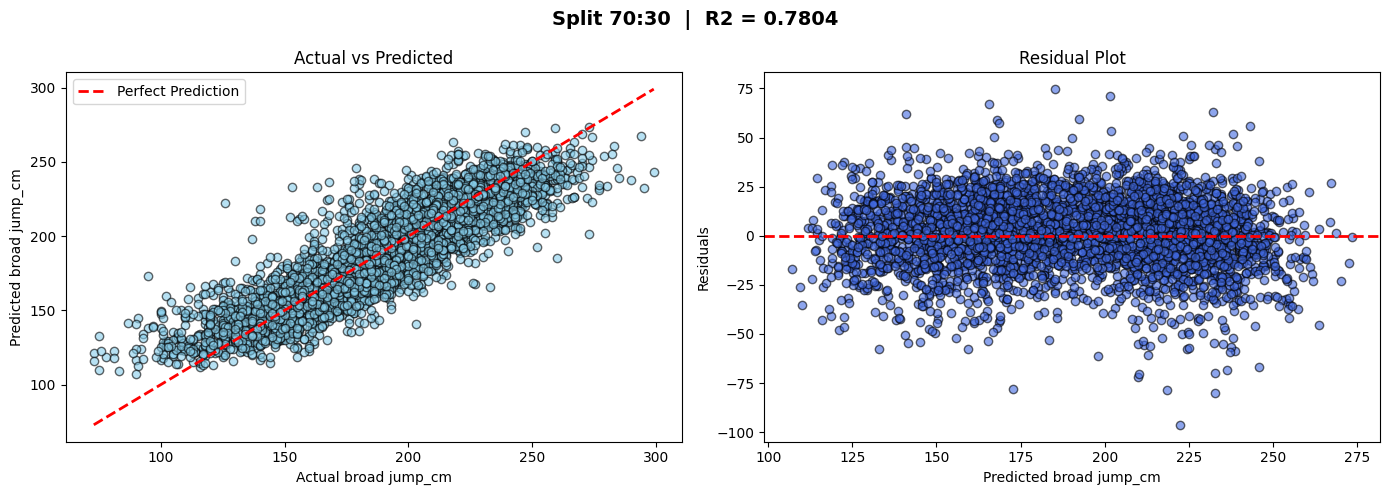


  Split 50:50  =>  After Log Transformation
  MSE  : 334.1825
  RMSE : 18.2807
  R2   : 0.7782 (77.82%)


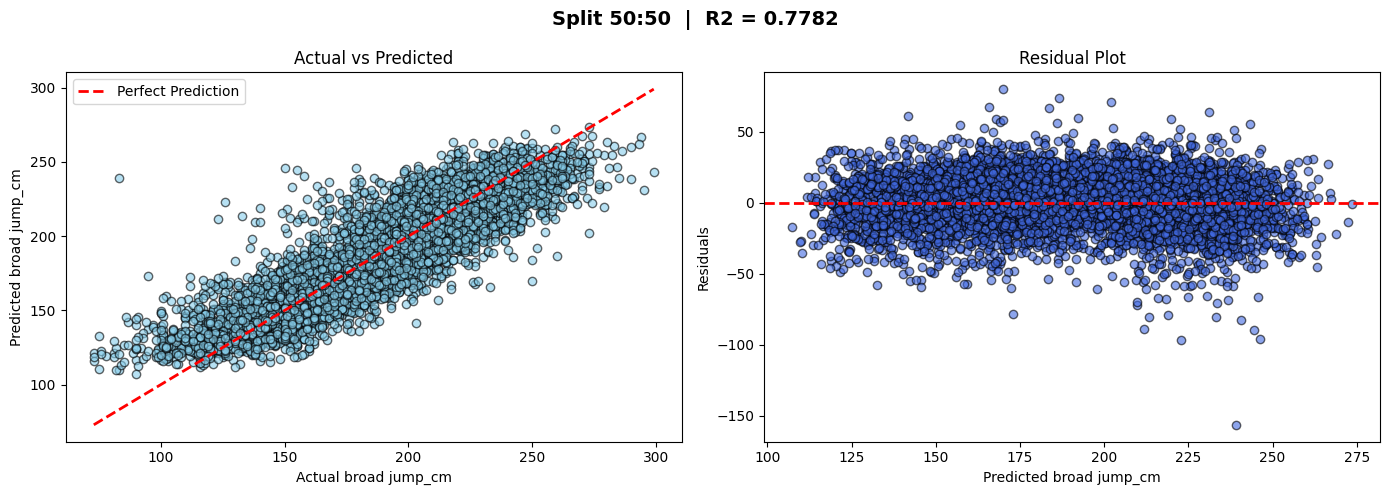


  COMPARISON SUMMARY
  Split               MSE       RMSE         R2
  ------------------------------------------
  80:20          329.0002    18.1384     0.7810
  70:30          328.3357    18.1200     0.7804
  50:50          334.1825    18.2807     0.7782

  5-Fold Cross Validation (After Log Transformation)
  Average R2 (5-Fold): 0.7797 (+-0.0054)


In [ ]:
# ====================== FEATURES & TARGET ======================
df_reg['BMI'] = df_reg['weight_kg'] / ((df_reg['height_cm'] / 100) ** 2)

features_to_drop = ['sit and bend forward_cm']

X = df_reg.drop(columns=['class', 'broad jump_cm'] + features_to_drop)
y = df_reg['broad jump_cm']

# ====================== LOG TRANSFORMATION ======================
# Apply log transformation to reduce skewness in target variable
y_log = np.log1p(y)
print("Applied Log Transformation on target (broad jump_cm)\n")

# ====================== EVALUATE FUNCTION ======================
def evaluate_log_model(X, y_log, test_size=0.2):
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=test_size, random_state=42)

    # Standardize features (mean=0, std=1)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_s, y_train_log)    # Train Linear Regression model on scaled data

    y_pred_log  = model.predict(X_test_s)
    y_test_orig = np.expm1(y_test_log)       # Predict on test data (log scale)
    y_pred_orig = np.expm1(y_pred_log)       # Convert predictions back to original scale

    mse  = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_orig, y_pred_orig)

    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    print(f"\n{'='*60}")
    print(f"  Split {train_pct}:{test_pct}  =>  After Log Transformation")
    print(f"{'='*60}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R2   : {r2:.4f} ({r2*100:.2f}%)")

    # ====================== PLOTS ======================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Split {train_pct}:{test_pct}  |  R2 = {r2:.4f}', fontsize=14, fontweight='bold')

    axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.6, color='skyblue', edgecolor='k')
    axes[0].plot([y_test_orig.min(), y_test_orig.max()],
                 [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual broad jump_cm')
    axes[0].set_ylabel('Predicted broad jump_cm')
    axes[0].set_title('Actual vs Predicted')
    axes[0].legend()

    residuals = y_test_orig - y_pred_orig
    axes[1].scatter(y_pred_orig, residuals, alpha=0.6, color='royalblue', edgecolor='k')
    axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted broad jump_cm')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Plot')

    plt.tight_layout()
    plt.show()

    return r2, rmse, mse


# ====================== RUN 3 SPLITS ======================
splits  = [0.2, 0.3, 0.5]
results = {}

for test_size in splits:
    r2, rmse, mse = evaluate_log_model(X, y_log, test_size=test_size)
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)
    results[f"{train_pct}:{test_pct}"] = {"R2": r2, "RMSE": rmse, "MSE": mse}

# ====================== COMPARISON TABLE ======================
print(f"\n{'='*60}")
print(f"  COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"  {'Split':<12} {'MSE':>10} {'RMSE':>10} {'R2':>10}")
print(f"  {'-'*42}")
for split, metrics in results.items():
    print(f"  {split:<12} {metrics['MSE']:>10.4f} {metrics['RMSE']:>10.4f} {metrics['R2']:>10.4f}")

# ====================== K-Fold Cross Validation ======================
print(f"\n{'='*60}")
print("  5-Fold Cross Validation (After Log Transformation)")
print(f"{'='*60}")

kf        = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

for train_idx, val_idx in kf.split(X):
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X.iloc[train_idx])
    X_val  = scaler.transform(X.iloc[val_idx])

    y_tr_log  = y_log.iloc[train_idx]
    y_val_log = y_log.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr_log)

    y_val_pred = np.expm1(model.predict(X_val))
    y_val_orig = np.expm1(y_val_log)

    r2_scores.append(r2_score(y_val_orig, y_val_pred))

print(f"  Average R2 (5-Fold): {np.mean(r2_scores):.4f} (+-{np.std(r2_scores):.4f})")